# Image Captioning Aksara Lontara
## Fine-Tuning BLIP | Tesis S2

Notebook ini menjalankan **seluruh pipeline** dalam satu proses:
1. Mount Google Drive & Install Library
2. Persiapan Dataset → Training → Evaluasi → Inference

> **Pastikan runtime menggunakan GPU** (Runtime → Change runtime type → GPU)

In [1]:
# ═══════════════════════════════════════════════════════════════
# SETUP: Mount Google Drive & Install Library
# ═══════════════════════════════════════════════════════════════
import os
try:
    os.chdir('/content')
except OSError:
    pass

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/ImageCaptioning'
LOCAL_DIR = '/content/ImageCaptioning'

# Copy dataset dari Drive ke local (lebih stabil & cepat)
assert os.path.exists(DRIVE_DIR), f'ERROR: {DRIVE_DIR} tidak ditemukan!'
!rm -rf {LOCAL_DIR}
!cp -r {DRIVE_DIR} {LOCAL_DIR}

os.chdir(LOCAL_DIR)
print(f'\u2705 Working directory: {os.getcwd()}')
print(f'\u2705 Isi folder: {os.listdir(".")}')

# Install library
!pip install -q transformers Pillow nltk rouge-score tqdm

import torch
print(f'\u2705 PyTorch: {torch.__version__}')
print(f'\u2705 CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'\u2705 GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
✅ Working directory: /content/ImageCaptioning
✅ Isi folder: ['.gitignore', 'inference_multi_character.ipynb', 'prompt.txt', 'Image_Captioning_Aksara_Lontara.ipynb', 'requirements.txt', 'README.md', 'doc', 'dataset', 'datatest', 'inference_local.ipynb']
  Preparing metadata (setup.py) ... done
✅ PyTorch: 2.10.0+cu128
✅ CUDA: True
✅ GPU: Tesla T4


Device: cuda

  TAHAP 1: PERSIAPAN DATASET
Caption dimuat: 95 entri
Total pasang: 475
Split: Train=380, Val=47, Test=48
  train: 95 gambar diproses
  val: 40 gambar diproses
  test: 37 gambar diproses
✅ Persiapan dataset selesai!

  TAHAP 2: FINE-TUNING BLIP
Memuat model BLIP...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

Epoch 18/20 | Train: 0.0493 | Val: 0.2057


Epoch 19/20 | Train: 0.0476 | Val: 0.2078


Epoch 20/20 | Train: 0.0467 | Val: 0.2059 | BLEU-4: 17.9% | METEOR: 36.5% | ROUGE-L: 38.2%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training selesai! Best Val Loss: 0.1906


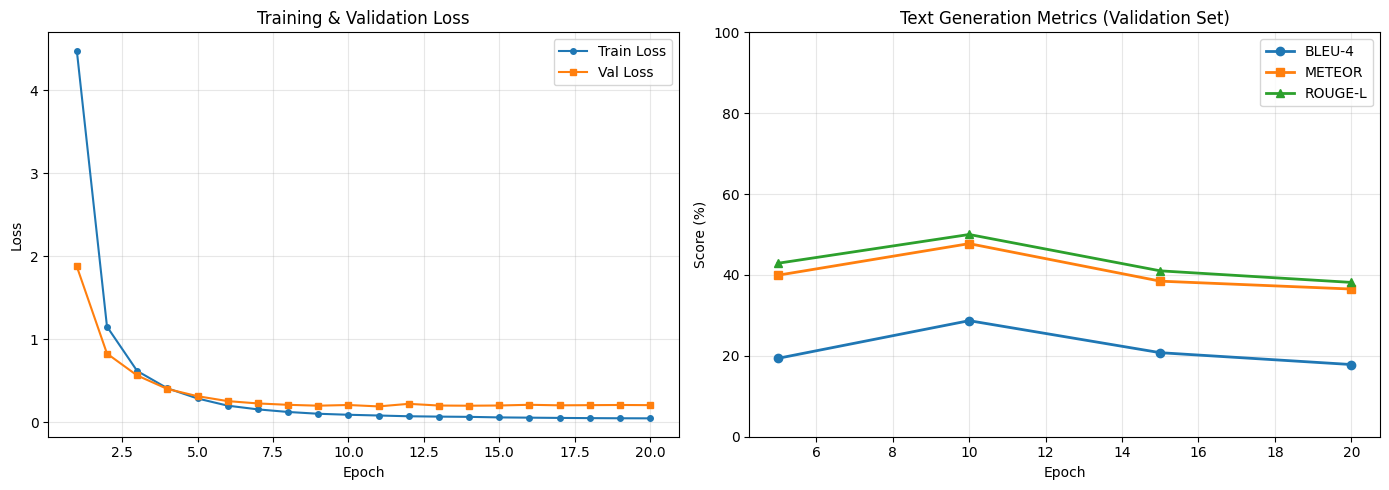


┌─────────┬──────────┬──────────┬──────────┐
│  Epoch  │  BLEU-4  │  METEOR  │ ROUGE-L  │
├─────────┼──────────┼──────────┼──────────┤
│     5   │  19.39%  │  39.94%  │  42.90%  │
│    10   │  28.70%  │  47.75%  │  50.01%  │
│    15   │  20.78%  │  38.47%  │  41.02%  │
│    20   │  17.85%  │  36.52%  │  38.16%  │
└─────────┴──────────┴──────────┴──────────┘

  TAHAP 3: EVALUASI MODEL (TEST SET)


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model evaluasi dimuat (best model).
Data test: 48 entri


Evaluasi Test Set: 100%|██████████| 37/37 [00:31<00:00,  1.19it/s]



  HASIL EVALUASI — TEST SET
┌────────────┬──────────┐
│   Metrik   │   Skor   │
├────────────┼──────────┤
│ BLEU-1     │  37.66%  │
│ BLEU-2     │  28.56%  │
│ BLEU-3     │  20.43%  │
│ BLEU-4     │  14.78%  │
│ METEOR     │  32.66%  │
│ ROUGE-L    │  35.82%  │
└────────────┴──────────┘

  Akurasi Identifikasi per Karakter Dasar:
┌──────────────┬───────┬────────┬──────────┐
│   Karakter   │ Total │ Benar  │ Akurasi  │
├──────────────┼───────┼────────┼──────────┤
│ a            │    3  │     3  │  100.0%  │
│ ba           │    2  │     2  │  100.0%  │
│ ca           │    3  │     1  │   33.3%  │
│ da           │    2  │     2  │  100.0%  │
│ ga           │    3  │     3  │  100.0%  │
│ ha           │    2  │     2  │  100.0%  │
│ ja           │    1  │     0  │    0.0%  │
│ la           │    2  │     0  │    0.0%  │
│ ma           │    1  │     1  │  100.0%  │
│ na           │    1  │     0  │    0.0%  │
│ nga          │    2  │     2  │  100.0%  │
│ nya          │    2  │     1  │   5

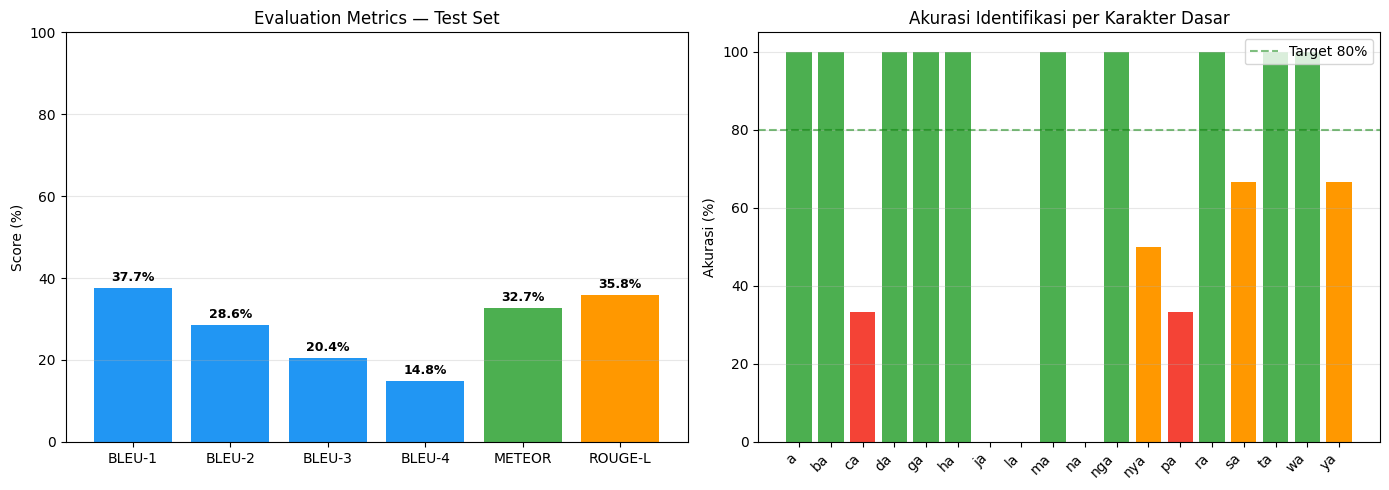


✅ Hasil evaluasi disimpan: hasil_evaluasi/hasil_evaluasi.json

  TAHAP 4: INFERENCE & VISUALISASI
  ltr-01.png → karakter lontara pada gambar ini adalah a dengan bentuk melengkung dan titik hitam di bagian bawah.
  ltr-03.png → karakter lontara pada gambar ini adalah u dengan bentuk melengkung dan titik hitam di bagian bawah.
  ltr-04.png → karakter e memiliki pola garis melengkung dengan simbol tambahan di bagian kiri
  ltr-09.png → aksara pada gambar ini merupakan karakter be dengan bentuk melengkung di bagian atas
  ltr-10.png → aksara pada gambar ini merupakan karakter bo dengan tanda tambahan di sisi kanan.
  ltr-11.png → karakter ca memiliki pola garis panjang dan bentuk yang melengkung


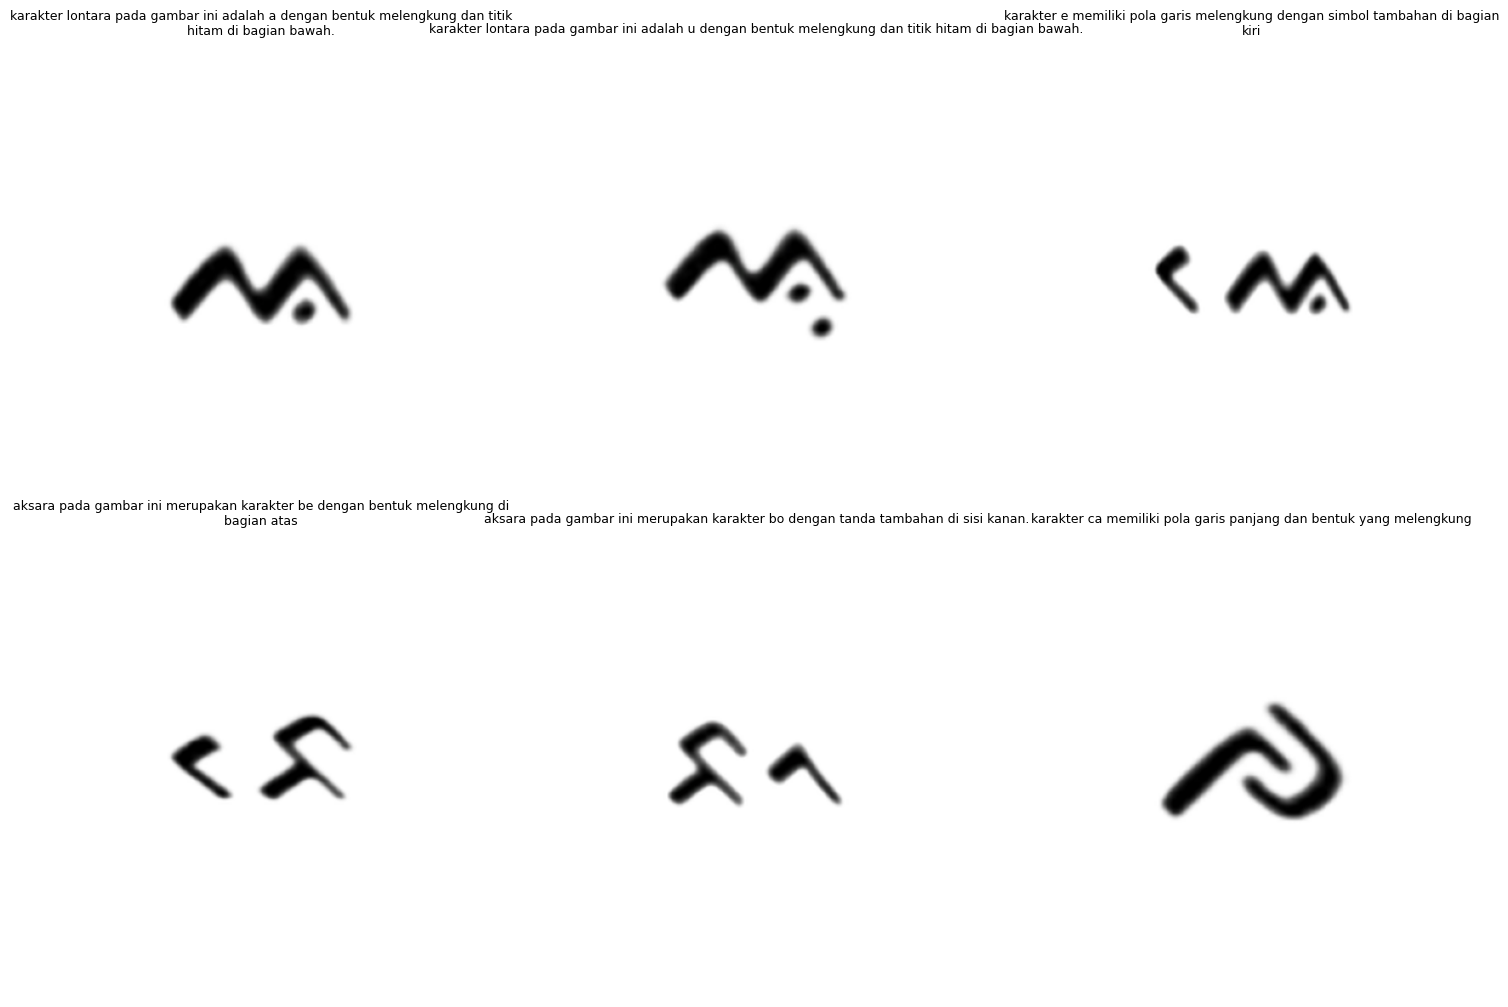


  TAHAP 5: MENYIMPAN HASIL KE GOOGLE DRIVE
  ✅ model/ → Drive
  ✅ hasil_evaluasi/ → Drive

  ✅ SELURUH PIPELINE SELESAI!
  Model terbaik : /content/drive/MyDrive/ImageCaptioning/model/blip_lontara/best_model
  Hasil evaluasi: /content/drive/MyDrive/ImageCaptioning/hasil_evaluasi/


In [2]:
# ═══════════════════════════════════════════════════════════════
# PIPELINE LENGKAP: Prepare → Train → Evaluate → Inference
# ═══════════════════════════════════════════════════════════════

import os
import json
import random
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


# ═══════════════════════════════════════════════════════════════
# TAHAP 1: PERSIAPAN DATASET
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('  TAHAP 1: PERSIAPAN DATASET')
print('=' * 60)

RAW_IMAGE_DIR = 'dataset/images'
CAPTION_FILE  = 'dataset/captions.json'
OUTPUT_DIR    = 'dataset/processed'
IMAGE_SIZE    = 384
RANDOM_SEED   = 42

KARAKTER_DASAR = [
    'a', 'ba', 'ca', 'da', 'ga',
    'ha', 'ja', 'ka', 'la', 'ma',
    'na', 'nga', 'nya', 'pa', 'ra',
    'sa', 'ta', 'wa', 'ya'
]
VOKAL = ['a', 'i', 'u', 'e', 'o']

# Buat mapping ltr-XX → karakter
mapping = {}
idx = 1
for dasar in KARAKTER_DASAR:
    for vokal in VOKAL:
        ltr_name = f'ltr-{idx:02d}'
        mapping[ltr_name] = {'karakter': dasar, 'vokal': vokal}
        idx += 1

# Buat folder output
for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUTPUT_DIR}/{split}/images', exist_ok=True)

# Load captions.json
with open(CAPTION_FILE, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
print(f'Caption dimuat: {len(raw_data)} entri')

# Flatten: 1 gambar x 5 caption = 5 pasang
flat_data = []
for item in raw_data:
    ltr_name = item['images']
    img_filename = f'{ltr_name}.png'
    info = mapping.get(ltr_name, {})
    for caption in item['captions']:
        flat_data.append({
            'image': img_filename,
            'caption': caption,
            'karakter': info.get('karakter', ''),
            'vokal': info.get('vokal', ''),
        })
print(f'Total pasang: {len(flat_data)}')

# Split dataset
random.seed(RANDOM_SEED)
random.shuffle(flat_data)
n = len(flat_data)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_data = flat_data[:n_train]
val_data = flat_data[n_train:n_train + n_val]
test_data = flat_data[n_train + n_val:]
print(f'Split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}')

# Simpan JSON per split
for name, data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    path = f'{OUTPUT_DIR}/{name}/captions_{name}.json'
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

# Resize & copy gambar per split
for name, data in [('train', train_data), ('val', val_data), ('test', test_data)]:
    processed = set()
    errors = []
    for item in data:
        img = item['image']
        if img in processed:
            continue
        processed.add(img)
        src = os.path.join(RAW_IMAGE_DIR, img)
        dst = os.path.join(OUTPUT_DIR, name, 'images', img)
        if os.path.exists(src):
            try:
                im = Image.open(src).convert('RGB')
                im_resized = im.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                im_resized.save(dst, format='PNG')
                Image.open(dst).verify()
            except Exception as e:
                errors.append(f'{img}: {e}')
    print(f'  {name}: {len(processed)} gambar diproses' + (f' ({len(errors)} error)' if errors else ''))

print('✅ Persiapan dataset selesai!')


# ═══════════════════════════════════════════════════════════════
# TAHAP 2: FINE-TUNING BLIP
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('  TAHAP 2: FINE-TUNING BLIP')
print('=' * 60)

MODEL_NAME = 'Salesforce/blip-image-captioning-base'
MODEL_OUTPUT = 'model/blip_lontara'
NUM_EPOCHS = 20
BATCH_SIZE = 8
LR = 2e-5
MAX_LENGTH = 64
EVAL_EVERY = 5   # Evaluasi text generation setiap N epoch

os.makedirs(MODEL_OUTPUT, exist_ok=True)


# ─── Data Augmentation ───

def augment_image(image, image_size=384):
    """
    Augmentasi simulasi kondisi crop multi-karakter.
    Diterapkan HANYA pada training dengan probabilitas 50%.
    """
    if random.random() > 0.5:
        return image

    img_w, img_h = image.size
    aug_type = random.choice(['scale', 'scale_shift', 'rotate'])

    if aug_type in ('scale', 'scale_shift'):
        scale = random.uniform(0.5, 0.9)
        new_w = max(1, int(img_w * scale))
        new_h = max(1, int(img_h * scale))
        resized = image.resize((new_w, new_h), Image.LANCZOS)
        canvas = Image.new('RGB', (image_size, image_size), (255, 255, 255))
        if aug_type == 'scale':
            paste_x = (image_size - new_w) // 2
            paste_y = (image_size - new_h) // 2
        else:
            max_offset = int(image_size * 0.15)
            paste_x = (image_size - new_w) // 2 + random.randint(-max_offset, max_offset)
            paste_y = (image_size - new_h) // 2 + random.randint(-max_offset, max_offset)
            paste_x = max(0, min(paste_x, image_size - new_w))
            paste_y = max(0, min(paste_y, image_size - new_h))
        canvas.paste(resized, (paste_x, paste_y))
        return canvas
    elif aug_type == 'rotate':
        angle = random.uniform(-5, 5)
        return image.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=(255, 255, 255))
    return image


class AksaraDataset(Dataset):
    def __init__(self, json_file, image_dir, processor, augment=False):
        with open(json_file, 'r', encoding='utf-8') as f:
            self.data = json.load(f)
        self.image_dir = image_dir
        self.processor = processor
        self.augment = augment
        print(f'  Dataset: {len(self.data)} pasang dari {json_file}' +
              (' [+augmentasi]' if augment else ''))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, os.path.basename(item['image']))
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (384, 384), (255, 255, 255))
        if self.augment:
            image = augment_image(image, image_size=IMAGE_SIZE)
        encoding = self.processor(
            images=image, text=item['caption'],
            padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        )
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        pixel_values = encoding['pixel_values'].squeeze()
        labels = input_ids.clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {'pixel_values': pixel_values, 'input_ids': input_ids,
                'attention_mask': attention_mask, 'labels': labels}


# ─── Fungsi Evaluasi Text Generation ───

def evaluate_generation(model, processor, val_json_path, val_image_dir):
    """Evaluasi text generation: BLEU-4, METEOR, ROUGE-L pada validation/test set."""
    model.eval()
    with open(val_json_path, 'r', encoding='utf-8') as f:
        val_items = json.load(f)

    gambar_dict = {}
    for item in val_items:
        key = item['image']
        if key not in gambar_dict:
            gambar_dict[key] = []
        gambar_dict[key].append(item['caption'])

    referensi_list = []
    hipotesis_list = []

    for image_key, captions in gambar_dict.items():
        img_path = os.path.join(val_image_dir, os.path.basename(image_key))
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            continue
        inputs = processor(images=image, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            output = model.generate(**inputs, max_length=64, num_beams=4, early_stopping=True)
        pred = processor.decode(output[0], skip_special_tokens=True)
        refs = [cap.lower().split() for cap in captions]
        hyp = pred.lower().split()
        referensi_list.append(refs)
        hipotesis_list.append(hyp)

    if not referensi_list:
        return {'BLEU-4': 0, 'METEOR': 0, 'ROUGE-L': 0}

    smoother = SmoothingFunction().method1
    bleu4 = corpus_bleu(referensi_list, hipotesis_list,
                        weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

    meteor_scores = [meteor_score(refs, hyp) for refs, hyp in zip(referensi_list, hipotesis_list)]
    meteor_avg = np.mean(meteor_scores)

    rouge_sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rouge_scores = []
    for refs, hyp in zip(referensi_list, hipotesis_list):
        hyp_str = ' '.join(hyp)
        scores = [rouge_sc.score(' '.join(r), hyp_str)['rougeL'].fmeasure for r in refs]
        rouge_scores.append(max(scores))
    rouge_avg = np.mean(rouge_scores)

    return {'BLEU-4': round(bleu4*100, 2), 'METEOR': round(meteor_avg*100, 2), 'ROUGE-L': round(rouge_avg*100, 2)}


# Load model
print('Memuat model BLIP...')
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
print(f'Model dimuat: {sum(p.numel() for p in model.parameters()):,} parameter')

# DataLoader
train_ds = AksaraDataset(f'{OUTPUT_DIR}/train/captions_train.json', f'{OUTPUT_DIR}/train/images', processor, augment=True)
val_ds = AksaraDataset(f'{OUTPUT_DIR}/val/captions_val.json', f'{OUTPUT_DIR}/val/images', processor, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=total_steps)
print(f'Total steps: {total_steps}')

# ─── Training Loop + Evaluasi Generasi Periodik ───
history = {'train_loss': [], 'val_loss': [], 'gen_metrics': []}
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]', leave=False):
        pv = batch['pixel_values'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        am = batch['attention_mask'].to(DEVICE)
        lb = batch['labels'].to(DEVICE)
        outputs = model(pixel_values=pv, input_ids=ids, attention_mask=am, labels=lb)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    # Validation loss
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]', leave=False):
            pv = batch['pixel_values'].to(DEVICE)
            ids = batch['input_ids'].to(DEVICE)
            am = batch['attention_mask'].to(DEVICE)
            lb = batch['labels'].to(DEVICE)
            outputs = model(pixel_values=pv, input_ids=ids, attention_mask=am, labels=lb)
            total_loss += outputs.loss.item()
    val_loss = total_loss / len(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Evaluasi text generation setiap EVAL_EVERY epoch
    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        gen_metrics = evaluate_generation(
            model, processor,
            f'{OUTPUT_DIR}/val/captions_val.json',
            f'{OUTPUT_DIR}/val/images'
        )
        history['gen_metrics'].append({'epoch': epoch, **gen_metrics})
        print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} '
              f'| BLEU-4: {gen_metrics["BLEU-4"]:.1f}% | METEOR: {gen_metrics["METEOR"]:.1f}% '
              f'| ROUGE-L: {gen_metrics["ROUGE-L"]:.1f}%')
    else:
        print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_dir = f'{MODEL_OUTPUT}/best_model'
        model.save_pretrained(best_dir)
        processor.save_pretrained(best_dir)
        print(f'  ⭐ Best model saved! Val Loss: {best_val_loss:.4f}')

    # Checkpoint setiap 5 epoch
    if epoch % 5 == 0:
        ckpt_dir = f'{MODEL_OUTPUT}/checkpoint_epoch_{epoch}'
        os.makedirs(ckpt_dir, exist_ok=True)
        model.save_pretrained(ckpt_dir)
        processor.save_pretrained(ckpt_dir)

# Simpan history
with open(f'{MODEL_OUTPUT}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n✅ Training selesai! Best Val Loss: {best_val_loss:.4f}')

# ─── Plot: Loss + Generation Metrics ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, NUM_EPOCHS+1), history['train_loss'], label='Train Loss', marker='o', markersize=4)
ax1.plot(range(1, NUM_EPOCHS+1), history['val_loss'], label='Val Loss', marker='s', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

if history['gen_metrics']:
    gen_epochs = [m['epoch'] for m in history['gen_metrics']]
    ax2.plot(gen_epochs, [m['BLEU-4'] for m in history['gen_metrics']], label='BLEU-4', marker='o', linewidth=2)
    ax2.plot(gen_epochs, [m['METEOR'] for m in history['gen_metrics']], label='METEOR', marker='s', linewidth=2)
    ax2.plot(gen_epochs, [m['ROUGE-L'] for m in history['gen_metrics']], label='ROUGE-L', marker='^', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score (%)')
    ax2.set_title('Text Generation Metrics (Validation Set)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f'{MODEL_OUTPUT}/training_plot.png', dpi=150)
plt.show()

# ─── Tabel Ringkasan Metrik per Epoch ───
if history['gen_metrics']:
    print('\n┌─────────┬──────────┬──────────┬──────────┐')
    print('│  Epoch  │  BLEU-4  │  METEOR  │ ROUGE-L  │')
    print('├─────────┼──────────┼──────────┼──────────┤')
    for m in history['gen_metrics']:
        print(f'│   {m["epoch"]:>3}   │  {m["BLEU-4"]:>5.2f}%  │  {m["METEOR"]:>5.2f}%  │  {m["ROUGE-L"]:>5.2f}%  │')
    print('└─────────┴──────────┴──────────┴──────────┘')


# ═══════════════════════════════════════════════════════════════
# TAHAP 3: EVALUASI LENGKAP (TEST SET)
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('  TAHAP 3: EVALUASI MODEL (TEST SET)')
print('=' * 60)

best_dir = f'{MODEL_OUTPUT}/best_model'
eval_processor = BlipProcessor.from_pretrained(best_dir)
eval_model = BlipForConditionalGeneration.from_pretrained(best_dir).to(DEVICE)
eval_model.eval()
print('Model evaluasi dimuat (best model).')

with open(f'{OUTPUT_DIR}/test/captions_test.json', 'r', encoding='utf-8') as f:
    test_items = json.load(f)
print(f'Data test: {len(test_items)} entri')

# Kelompokkan per gambar
gambar_dict = {}
for item in test_items:
    key = item['image']
    if key not in gambar_dict:
        gambar_dict[key] = {'captions': [], 'karakter': item.get('karakter', ''), 'vokal': item.get('vokal', '')}
    gambar_dict[key]['captions'].append(item['caption'])

# Generate & evaluate
referensi_list = []
hipotesis_list = []
hasil_detail = []

for image_key, info in tqdm(gambar_dict.items(), desc='Evaluasi Test Set'):
    img_path = os.path.join(f'{OUTPUT_DIR}/test/images', os.path.basename(image_key))
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception:
        continue
    inputs = eval_processor(images=image, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output = eval_model.generate(**inputs, max_length=64, num_beams=4, early_stopping=True)
    pred = eval_processor.decode(output[0], skip_special_tokens=True)

    refs = [cap.lower().split() for cap in info['captions']]
    hyp = pred.lower().split()
    referensi_list.append(refs)
    hipotesis_list.append(hyp)
    hasil_detail.append({
        'image': image_key, 'karakter': info['karakter'], 'vokal': info['vokal'],
        'caption_prediksi': pred, 'captions_referensi': info['captions']
    })

# Hitung semua metrik
smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(referensi_list, hipotesis_list, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(referensi_list, hipotesis_list, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(referensi_list, hipotesis_list, weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
bleu4 = corpus_bleu(referensi_list, hipotesis_list, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

meteor_scores_list = [meteor_score(refs, hyp) for refs, hyp in zip(referensi_list, hipotesis_list)]
meteor_avg = np.mean(meteor_scores_list)

rouge_sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
rouge_scores_list = []
for refs, hyp in zip(referensi_list, hipotesis_list):
    hyp_str = ' '.join(hyp)
    scores = [rouge_sc.score(' '.join(r), hyp_str)['rougeL'].fmeasure for r in refs]
    rouge_scores_list.append(max(scores))
rouge_avg = np.mean(rouge_scores_list)

# ─── Laporan Evaluasi Test Set ───
metrik = {
    'BLEU-1': bleu1*100, 'BLEU-2': bleu2*100,
    'BLEU-3': bleu3*100, 'BLEU-4': bleu4*100,
    'METEOR': meteor_avg*100, 'ROUGE-L': rouge_avg*100
}

print('\n' + '=' * 60)
print('  HASIL EVALUASI — TEST SET')
print('=' * 60)
print('┌────────────┬──────────┐')
print('│   Metrik   │   Skor   │')
print('├────────────┼──────────┤')
for k, v in metrik.items():
    print(f'│ {k:<10} │  {v:>5.2f}%  │')
print('└────────────┴──────────┘')

# ─── Evaluasi per Karakter Dasar ───
print('\n  Akurasi Identifikasi per Karakter Dasar:')
karakter_stats = {}
for item in hasil_detail:
    kar = item['karakter']
    if not kar:
        continue
    if kar not in karakter_stats:
        karakter_stats[kar] = {'total': 0, 'benar': 0}
    karakter_stats[kar]['total'] += 1
    if kar.lower() in item['caption_prediksi'].lower():
        karakter_stats[kar]['benar'] += 1

print('┌──────────────┬───────┬────────┬──────────┐')
print('│   Karakter   │ Total │ Benar  │ Akurasi  │')
print('├──────────────┼───────┼────────┼──────────┤')
total_benar = 0
total_semua = 0
for kar in sorted(karakter_stats.keys()):
    s = karakter_stats[kar]
    akurasi = (s['benar'] / s['total'] * 100) if s['total'] > 0 else 0
    total_benar += s['benar']
    total_semua += s['total']
    print(f'│ {kar:<12} │  {s["total"]:>3}  │   {s["benar"]:>3}  │  {akurasi:>5.1f}%  │')
print('├──────────────┼───────┼────────┼──────────┤')
akurasi_total = (total_benar / total_semua * 100) if total_semua > 0 else 0
print(f'│ {"TOTAL":<12} │  {total_semua:>3}  │   {total_benar:>3}  │  {akurasi_total:>5.1f}%  │')
print('└──────────────┴───────┴────────┴──────────┘')

# ─── Visualisasi Metrik ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

metrik_names = list(metrik.keys())
metrik_vals = list(metrik.values())
bars = ax1.bar(metrik_names, metrik_vals, color=['#2196F3','#2196F3','#2196F3','#2196F3','#4CAF50','#FF9800'])
ax1.set_ylabel('Score (%)')
ax1.set_title('Evaluation Metrics — Test Set')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrik_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

if karakter_stats:
    kar_names = sorted(karakter_stats.keys())
    kar_akurasi = [(karakter_stats[k]['benar']/karakter_stats[k]['total']*100)
                   if karakter_stats[k]['total'] > 0 else 0 for k in kar_names]
    bar_colors = ['#4CAF50' if a >= 80 else '#FF9800' if a >= 50 else '#F44336' for a in kar_akurasi]
    ax2.bar(kar_names, kar_akurasi, color=bar_colors)
    ax2.set_ylabel('Akurasi (%)')
    ax2.set_title('Akurasi Identifikasi per Karakter Dasar')
    ax2.set_ylim(0, 105)
    ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Target 80%')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
os.makedirs('hasil_evaluasi', exist_ok=True)
plt.savefig('hasil_evaluasi/evaluasi_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan hasil evaluasi lengkap
hasil_final = {
    'metrik': {k: round(v, 2) for k, v in metrik.items()},
    'akurasi_per_karakter': {k: round((v['benar']/v['total']*100) if v['total']>0 else 0, 1)
                             for k, v in karakter_stats.items()},
    'training_history': {
        'best_val_loss': round(best_val_loss, 4),
        'gen_metrics_per_epoch': history['gen_metrics']
    },
    'detail': hasil_detail
}
with open('hasil_evaluasi/hasil_evaluasi.json', 'w', encoding='utf-8') as f:
    json.dump(hasil_final, f, ensure_ascii=False, indent=2)
print('\n✅ Hasil evaluasi disimpan: hasil_evaluasi/hasil_evaluasi.json')


# ═══════════════════════════════════════════════════════════════
# TAHAP 4: INFERENCE & VISUALISASI
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('  TAHAP 4: INFERENCE & VISUALISASI')
print('=' * 60)

test_folder = f'{OUTPUT_DIR}/test/images'
test_images = sorted([f for f in os.listdir(test_folder) if f.endswith('.png')])[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

inference_results = []
for idx, img_name in enumerate(test_images):
    img_path = os.path.join(test_folder, img_name)
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception:
        continue
    inputs = eval_processor(images=image, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        output = eval_model.generate(**inputs, max_length=64, num_beams=4,
                                     early_stopping=True, no_repeat_ngram_size=2)
    caption = eval_processor.decode(output[0], skip_special_tokens=True)
    inference_results.append({'gambar': img_name, 'caption': caption})
    print(f'  {img_name} → {caption}')

    axes[idx].imshow(image)
    axes[idx].set_title(caption, fontsize=9, wrap=True)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('hasil_evaluasi/visualisasi_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()

with open('hasil_evaluasi/hasil_inference.json', 'w', encoding='utf-8') as f:
    json.dump(inference_results, f, ensure_ascii=False, indent=2)


# ═══════════════════════════════════════════════════════════════
# TAHAP 5: COPY HASIL KE GOOGLE DRIVE
# ═══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('  TAHAP 5: MENYIMPAN HASIL KE GOOGLE DRIVE')
print('=' * 60)

DRIVE_DIR = '/content/drive/MyDrive/ImageCaptioning'
LOCAL_DIR = '/content/ImageCaptioning'

for folder in ['model', 'hasil_evaluasi']:
    src = os.path.join(LOCAL_DIR, folder)
    dst = os.path.join(DRIVE_DIR, folder)
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f'  ✅ {folder}/ → Drive')

print('\n' + '=' * 60)
print('  ✅ SELURUH PIPELINE SELESAI!')
print(f'  Model terbaik : {DRIVE_DIR}/model/blip_lontara/best_model')
print(f'  Hasil evaluasi: {DRIVE_DIR}/hasil_evaluasi/')
print('=' * 60)